Figures will be saved in:
/home/mzhc13/master/complex-networks-airports/notebooks/../figures

LOADING NETWORK
Graph with 3397 nodes and 19231 edges

Nodes: 3397
Edges: 19231

COMMUNITY VISUALIZATION


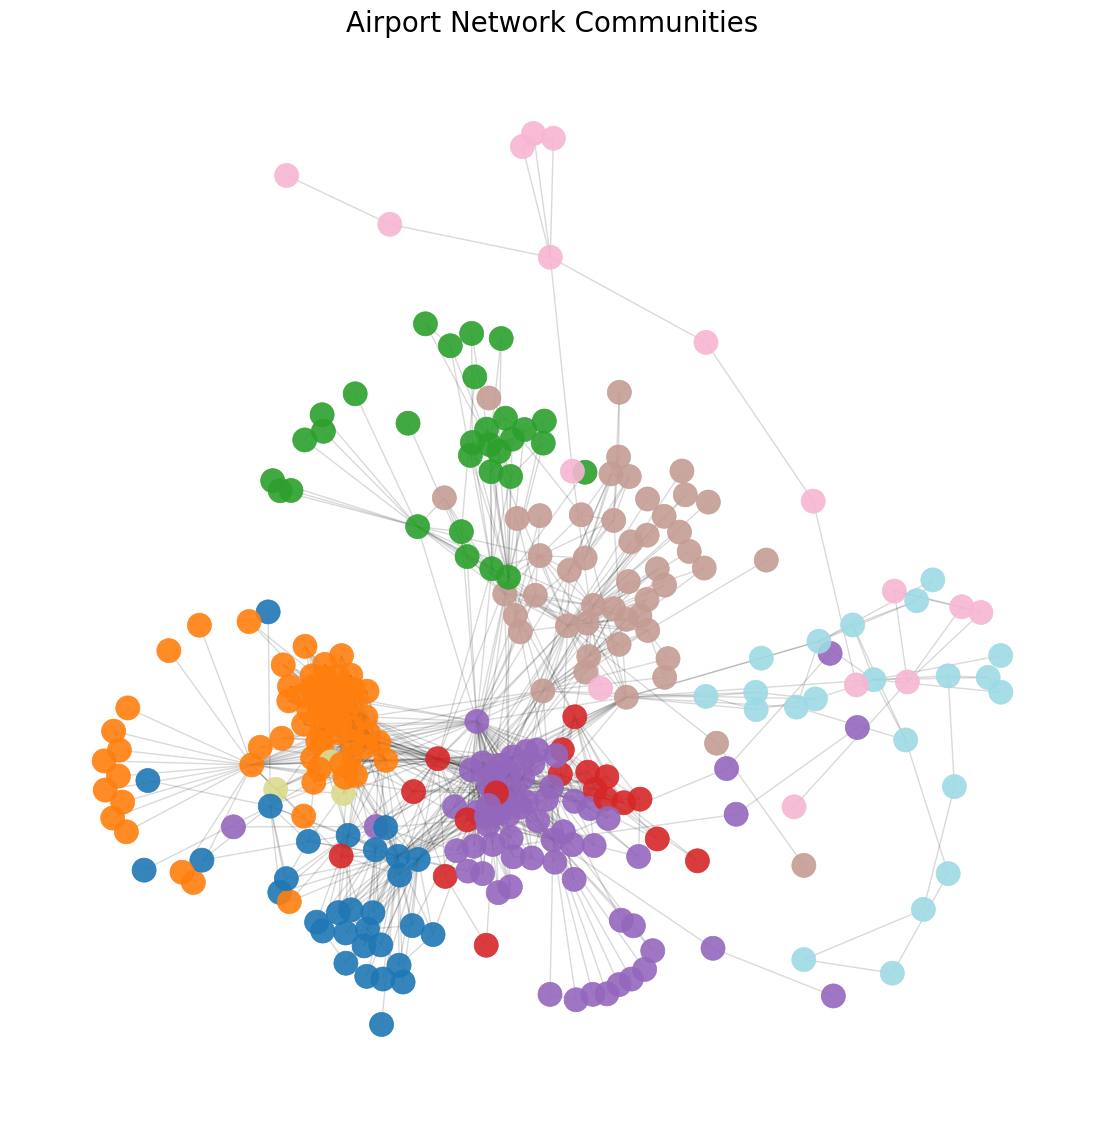


DEGREE DISTRIBUTION


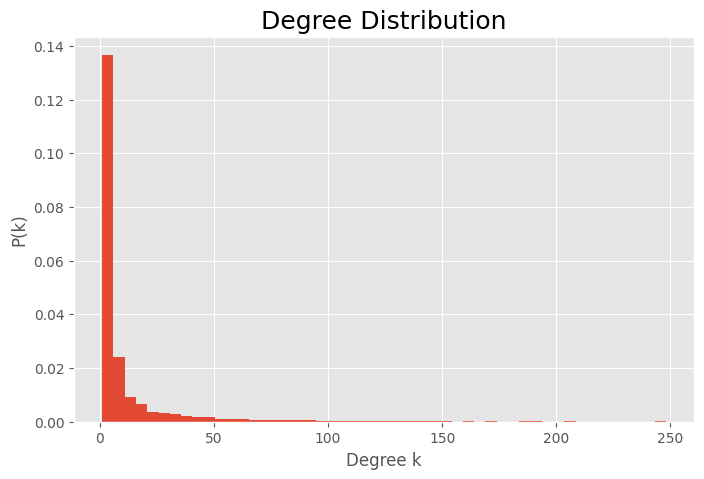

Estimated gamma: 1.3651573120369394


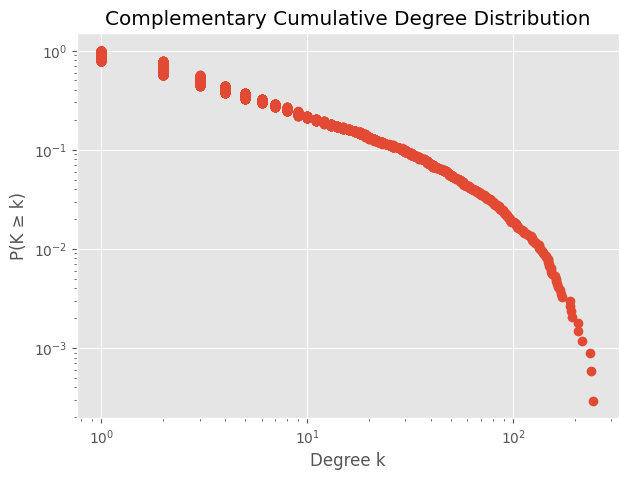

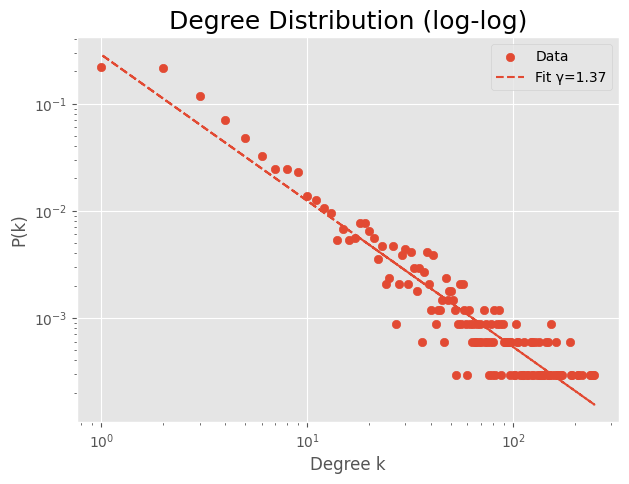


CLUSTERING ANALYSIS


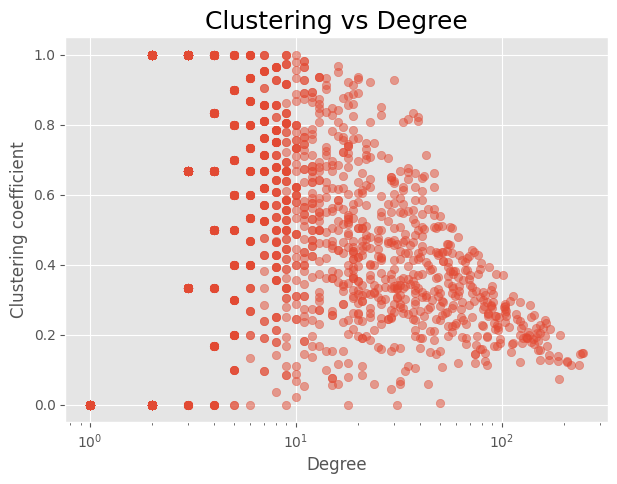


SPECTRAL ANALYSIS
Computing adjacency matrix...
Computing eigenvalues...
Largest eigenvalue: 69.851
Smallest eigenvalue: -25.069


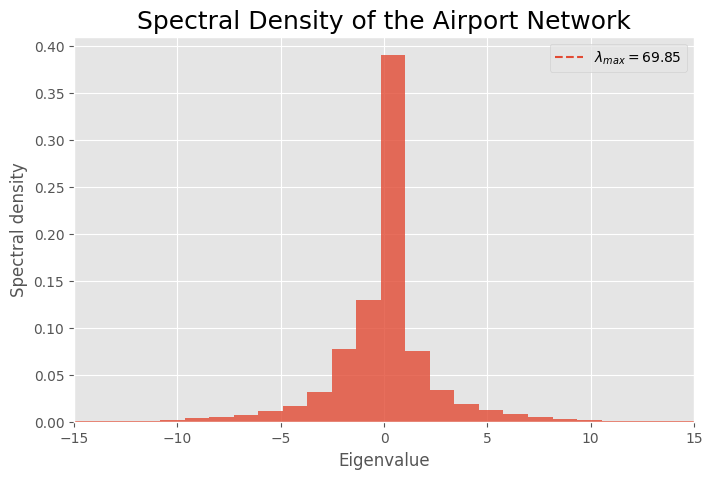


COMPARISON WITH ERDOS-RENYI AND BARABASI-ALBERT MODELS

Real network:
N = 3397
E = 19231
<k> = 11.322
C = 0.488
L = 4.103

Generating Erdős-Rényi network...

Erdős-Rényi network:
N = 3397
E = 19032
<k> = 11.205
C = 0.004
L = 3.632

Generating Barabási-Albert network...

Barabási-Albert network:
N = 3397
E = 16960
<k> = 9.985
C = 0.019
L = 3.332

DEGREE DISTRIBUTION COMPARISON


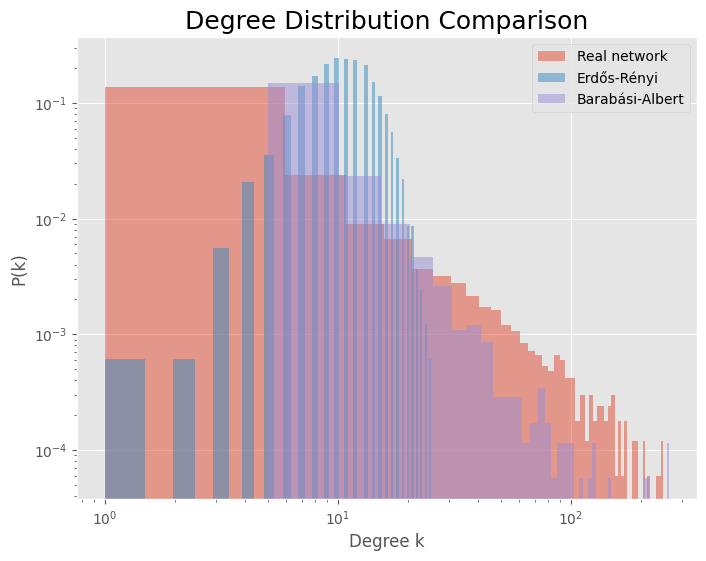


ROBUSTNESS ANALYSIS


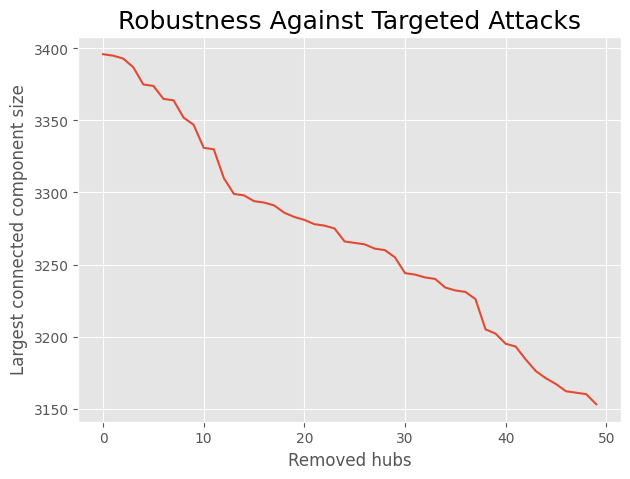


GEOGRAPHICAL VISUALIZATION
Nodes with coordinates: 3238
Drawing routes...
Drawing airports...


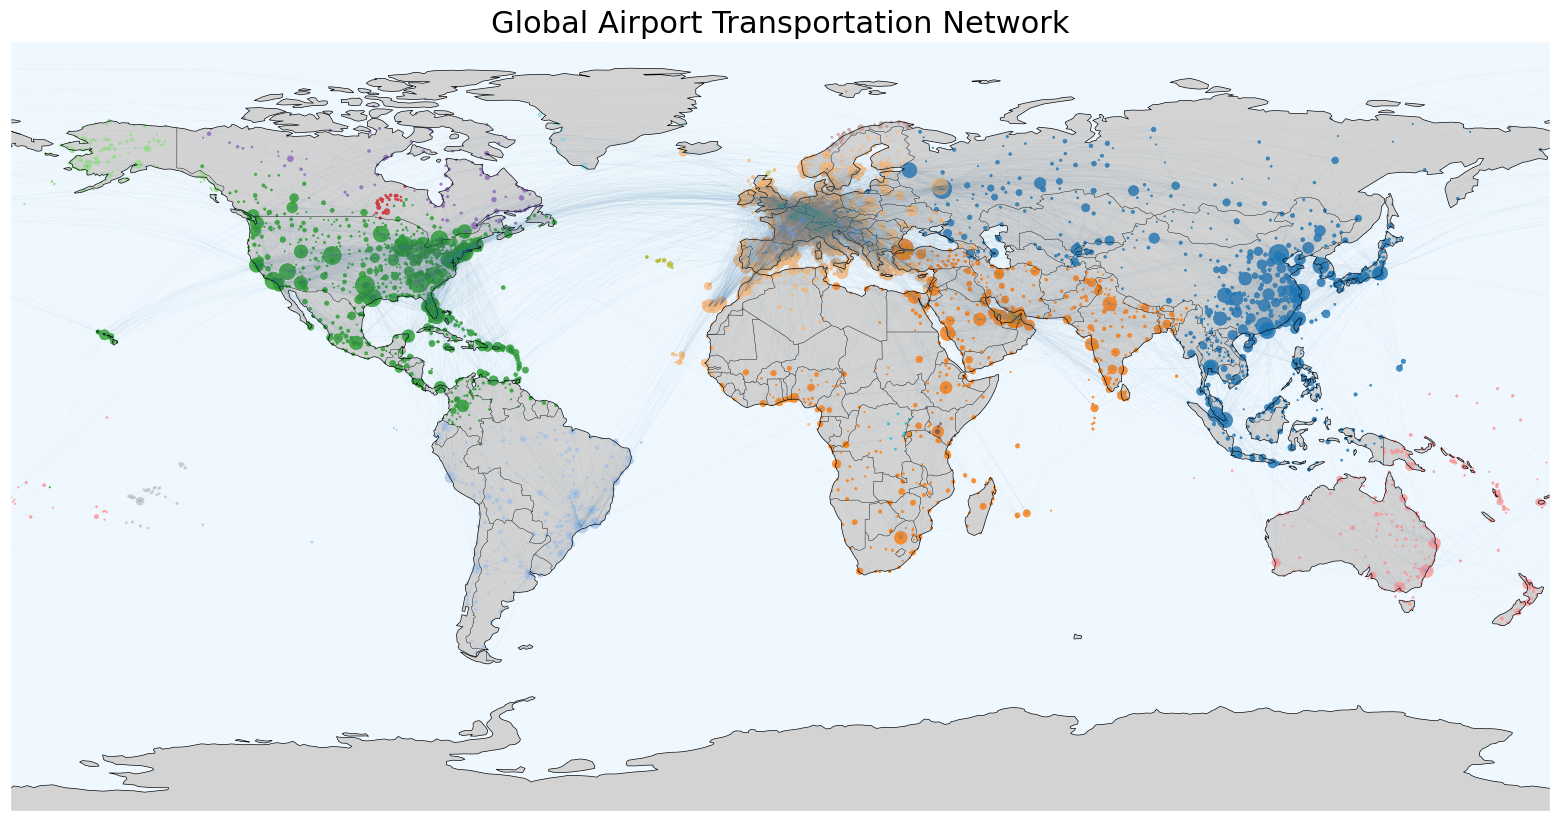


TOP HUBS


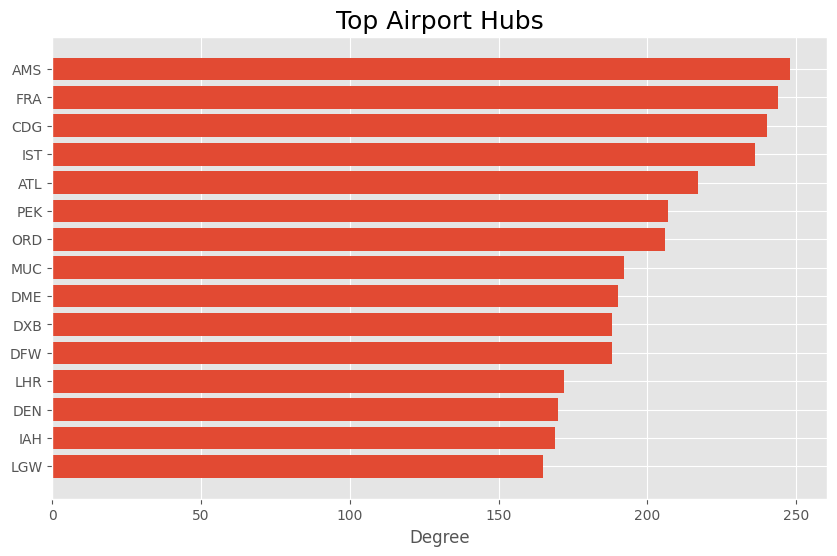


ALL FIGURES GENERATED


In [22]:

import warnings
warnings.filterwarnings("ignore")
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

plt.style.use("ggplot")


BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "../data"
FIGURES_DIR = BASE_DIR / "../figures"
FIGURES_DIR.mkdir(exist_ok=True)
print("Figures will be saved in:")
print(FIGURES_DIR)


print("\n" + "=" * 60)
print("LOADING NETWORK")
print("=" * 60)
with open(DATA_DIR / "airport_network.gpickle", "rb") as f:
    G_main = pickle.load(f)
print(G_main)
print("\nNodes:", G_main.number_of_nodes())
print("Edges:", G_main.number_of_edges())


degrees = dict(G_main.degree())
communities = nx.get_node_attributes(G_main,"community")
betweenness = nx.get_node_attributes(G_main,"betweenness")
clustering = nx.get_node_attributes(G_main,"clustering")


print("\n" + "=" * 60)
print("COMMUNITY VISUALIZATION")
print("=" * 60)
sample_nodes = list(G_main.nodes())[:300]
subgraph = G_main.subgraph(sample_nodes)
node_colors = [communities[node] for node in subgraph.nodes()]
node_sizes = [degrees[node] * 10 for node in subgraph.nodes()]

plt.figure(figsize=(14,14))
pos = nx.spring_layout(subgraph,k=0.15,seed=42)
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, cmap=plt.cm.tab20,alpha=0.9)
nx.draw_networkx_edges(subgraph,pos,alpha=0.15)
plt.title("Airport Network Communities",fontsize=20)
plt.axis("off")
plt.savefig(FIGURES_DIR / "communities.png", dpi=300,bbox_inches="tight")
plt.show()


print("\n" + "=" * 60)
print("DEGREE DISTRIBUTION")
print("=" * 60)
degree_values = list(degrees.values())
plt.figure(figsize=(8,5))
plt.hist(degree_values,bins=50,density=True)
plt.xlabel("Degree k")
plt.ylabel("P(k)")

plt.title("Degree Distribution",fontsize=18)
plt.savefig(FIGURES_DIR / "degree_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


degree_counts = Counter(degree_values)
k = np.array(list(degree_counts.keys()))
pk = np.array(list(degree_counts.values())) / len(degree_values)
mask = (k > 0) & (pk > 0)
k_fit = k[mask]
pk_fit = pk[mask]


log_k = np.log10(k_fit)
log_pk = np.log10(pk_fit)
coeffs = np.polyfit(log_k, log_pk, 1)
gamma = -coeffs[0]
fit_line = (10 ** coeffs[1]) * k_fit ** coeffs[0]
print("Estimated gamma:", gamma)


sorted_degrees = np.sort(degree_values)
ccdf = 1. - np.arange(1, len(sorted_degrees)+1) / len(sorted_degrees)
plt.figure(figsize=(7,5))
plt.loglog(sorted_degrees, ccdf, marker="o", linestyle="none")
plt.xlabel("Degree k")
plt.ylabel("P(K ≥ k)")
plt.title("Complementary Cumulative Degree Distribution")
plt.savefig( FIGURES_DIR / "ccdf_distribution.png",dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7,5))
plt.scatter(k_fit, pk_fit, label="Data")
plt.plot(k_fit, fit_line, linestyle="--", label=f"Fit γ={gamma:.2f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k")
plt.ylabel("P(k)")
plt.title("Degree Distribution (log-log)", fontsize=18)
plt.legend()
plt.savefig(FIGURES_DIR / "loglog_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 60)
print("CLUSTERING ANALYSIS")
print("=" * 60)

degrees_nodes = []
clustering_values = []
for node in G_main.nodes():
    degrees_nodes.append(degrees[node])
    clustering_values.append(clustering[node])
plt.figure(figsize=(7,5))
plt.scatter(degrees_nodes,clustering_values, alpha=0.5)
plt.xscale("log")
plt.xlabel("Degree")
plt.ylabel("Clustering coefficient")
plt.title("Clustering vs Degree", fontsize=18)

plt.savefig(FIGURES_DIR / "clustering_vs_degree.png", dpi=300, bbox_inches="tight")
plt.show()


print("\n" + "=" * 60)
print("SPECTRAL ANALYSIS")
print("=" * 60)
print("Computing adjacency matrix...")
A = nx.adjacency_matrix(G_main).todense()
print("Computing eigenvalues...")
eigenvalues = np.linalg.eigvals(A)
eigenvalues = np.real(eigenvalues)
lambda_max = np.max(eigenvalues)
lambda_min = np.min(eigenvalues)
print(f"Largest eigenvalue: {lambda_max:.3f}")
print(f"Smallest eigenvalue: {lambda_min:.3f}")
plt.figure(figsize=(8,5))
plt.hist(eigenvalues, bins=80,density=True, alpha=0.8)
plt.axvline(lambda_max,linestyle="--",label=fr"$\lambda_{{max}}={lambda_max:.2f}$")
plt.xlim(-15,15)
plt.xlabel("Eigenvalue")
plt.ylabel("Spectral density")
plt.title("Spectral Density of the Airport Network",fontsize=18)
plt.legend()
plt.savefig(FIGURES_DIR / "spectral_density_improved.png",
 dpi=300,  bbox_inches="tight")
plt.show()


print("\n" + "=" * 60)
print("COMPARISON WITH ERDOS-RENYI AND BARABASI-ALBERT MODELS")
print("=" * 60)
N = G_main.number_of_nodes()
E = G_main.number_of_edges()
avg_degree_real = np.mean([d for _, d in G_main.degree()])
clustering_real = nx.average_clustering(G_main)
path_real = nx.average_shortest_path_length(G_main)
print(f"\nReal network:")
print(f"N = {N}")
print(f"E = {E}")
print(f"<k> = {avg_degree_real:.3f}")
print(f"C = {clustering_real:.3f}")
print(f"L = {path_real:.3f}")


print("\nGenerating Erdős-Rényi network...")
p = (2 * E) / (N * (N - 1))
G_er = nx.erdos_renyi_graph(N, p, seed=42)
largest_cc_er = max(nx.connected_components(G_er), key=len)
G_er = G_er.subgraph(largest_cc_er).copy()
avg_degree_er = np.mean([d for _, d in G_er.degree()])
clustering_er = nx.average_clustering(G_er)
path_er = nx.average_shortest_path_length(G_er)
print("\nErdős-Rényi network:")
print(f"N = {G_er.number_of_nodes()}")
print(f"E = {G_er.number_of_edges()}")
print(f"<k> = {avg_degree_er:.3f}")
print(f"C = {clustering_er:.3f}")
print(f"L = {path_er:.3f}")

print("\nGenerating Barabási-Albert network...")
m = int(avg_degree_real / 2)
G_ba = nx.barabasi_albert_graph(N, m, seed=42)
avg_degree_ba = np.mean([d for _, d in G_ba.degree()])
clustering_ba = nx.average_clustering(G_ba)
path_ba = nx.average_shortest_path_length(G_ba)
print("\nBarabási-Albert network:")
print(f"N = {G_ba.number_of_nodes()}")
print(f"E = {G_ba.number_of_edges()}")
print(f"<k> = {avg_degree_ba:.3f}")
print(f"C = {clustering_ba:.3f}")
print(f"L = {path_ba:.3f}")




print("\n" + "=" * 60)
print("DEGREE DISTRIBUTION COMPARISON")
print("=" * 60)
deg_real = [d for _, d in G_main.degree()]
deg_er = [d for _, d in G_er.degree()]
deg_ba = [d for _, d in G_ba.degree()]

plt.figure(figsize=(8,6))
plt.hist(deg_real, bins=50, density=True, alpha=0.5,
 label="Real network")
plt.hist(deg_er, bins=50, density=True, alpha=0.5, label="Erdős-Rényi")
plt.hist(deg_ba, bins=50, density=True, alpha=0.5, label="Barabási-Albert")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k")
plt.ylabel("P(k)")
plt.title("Degree Distribution Comparison", fontsize=18)
plt.legend()
plt.savefig(FIGURES_DIR / "model_comparison_degree.png",
 dpi=300, bbox_inches="tight")
plt.show()





print("\n" + "=" * 60)
print("ROBUSTNESS ANALYSIS")
print("=" * 60)
G_attack = G_main.copy()
top_nodes = sorted(G_attack.degree(),key=lambda x: x[1],reverse=True)
sizes = []
for node, _ in top_nodes[:50]:
    G_attack.remove_node(node)
    if len(G_attack) == 0:
        break
    largest = max(nx.connected_components(G_attack),key=len)
    sizes.append(len(largest))
plt.figure(figsize=(7,5))
plt.plot(sizes)
plt.xlabel("Removed hubs")
plt.ylabel("Largest connected component size")
plt.title("Robustness Against Targeted Attacks",fontsize=18)
plt.savefig(FIGURES_DIR / "robustness.png", dpi=300, bbox_inches="tight")
plt.show()


print("\n" + "=" * 60)
print("GEOGRAPHICAL VISUALIZATION")
print("=" * 60)

airport_positions = {}
for node in G_main.nodes():
    if ("longitude" in G_main.nodes[node] and "latitude" in G_main.nodes[node]):
        airport_positions[node] = (G_main.nodes[node]["longitude"], G_main.nodes[node]["latitude"])


valid_nodes = [node for node in G_main.nodes() if node in airport_positions]
G_geo = G_main.subgraph(valid_nodes)
print("Nodes with coordinates:", G_geo.number_of_nodes())


fig = plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

ax.add_feature(cfeature.LAND,color="lightgray")
ax.add_feature(cfeature.OCEAN,color="aliceblue")
ax.add_feature(cfeature.COASTLINE,linewidth=0.5)
ax.add_feature( cfeature.BORDERS,linewidth=0.3)



print("Drawing routes...")
for u, v in G_geo.edges():
    if (u in airport_positions and v in airport_positions):
        lon1, lat1 = airport_positions[u]
        lon2, lat2 = airport_positions[v]
        ax.plot([lon1, lon2],[lat1, lat2],color="steelblue",
                linewidth=0.15,alpha=0.08,transform=ccrs.Geodetic())


print("Drawing airports...")
node_sizes = []
longitudes = []
latitudes = []
node_colors = []
for node in G_geo.nodes():
    lon, lat = airport_positions[node]
    longitudes.append(lon)
    latitudes.append(lat)
    node_sizes.append(degrees[node])
    node_colors.append(communities[node])
scatter = ax.scatter(longitudes,latitudes,s=node_sizes,
    c=node_colors,cmap="tab20",alpha=0.8,transform=ccrs.PlateCarree())

plt.title("Global Airport Transportation Network",fontsize=22)

plt.savefig(FIGURES_DIR / "geographical_network.png",dpi=300,bbox_inches="tight")
plt.show()


print("\n" + "=" * 60)
print("TOP HUBS")
print("=" * 60)

top_degree = sorted(degrees.items(),key=lambda x: x[1],reverse=True)[:15]
airports = [x[0] for x in top_degree]
values = [x[1] for x in top_degree]
plt.figure(figsize=(10,6))
plt.barh(airports[::-1],values[::-1])

plt.xlabel("Degree")
plt.title("Top Airport Hubs",fontsize=18)

plt.savefig(FIGURES_DIR / "top_hubs.png",dpi=300,bbox_inches="tight")
plt.show()


print("\n" + "=" * 60)
print("ALL FIGURES GENERATED")
print("=" * 60)
